In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.linear_model import Lasso,Ridge,ElasticNet
from sklearn.linear_model import LassoCV,RidgeCV,ElasticNetCV

from sklearn.linear_model import LogisticRegression,LinearRegression

In [3]:
df=pd.read_csv("/content/drive/MyDrive/Machine Learning - 2/Algerian Forest Fires Dataset/Algerian_forest_fires_dataset_CLEAN.csv")

In [4]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [5]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [6]:
# we dint need date month and year for the current model design
df=df.drop(["month","day","year"],axis=1)

In [7]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [8]:
df['Classes'].value_counts()

,count
Classes,
fire,131
not fire,101
fire,4
fire,2
not fire,2
not fire,1
not fire,1
not fire,1


In [9]:
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [10]:

df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [11]:
# Dividing the dependent and independent features
X=df.drop("FWI",axis=1)
y=df["FWI"]

In [12]:
#dividing the data into training and testing dataset

In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [14]:
X_train.shape,X_test.shape

((182, 11), (61, 11))

In [15]:
# Feature selection based on correlation of X data set

# 1.Get corr data
corr_matrix=X_train.corr()
# 2. Stack the matrix and filter out identical/mirrored pairs
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# 3. Sort in decreasing (descending) order
sorted_pairs = corr_pairs.sort_values(ascending=False).drop_duplicates()

# 4. Display the top 20 most correlated feature pairs
print(sorted_pairs.head(20))

BUI          DMC            0.983175
DC           BUI            0.942414
DMC          DC             0.868647
Classes      FFMC           0.781259
ISI          FFMC           0.750799
Classes      ISI            0.742977
Temperature  FFMC           0.694768
DMC          ISI            0.685656
ISI          BUI            0.643818
Temperature  ISI            0.629848
DMC          FFMC           0.620807
Classes      DMC            0.617273
             BUI            0.612239
FFMC         BUI            0.607210
Classes      DC             0.543581
Temperature  Classes        0.542141
DC           FFMC           0.524101
             ISI            0.513701
Temperature  DMC            0.498173
BUI          Temperature    0.473609
dtype: float64


# Checkign for multicollinearity

<Axes: >

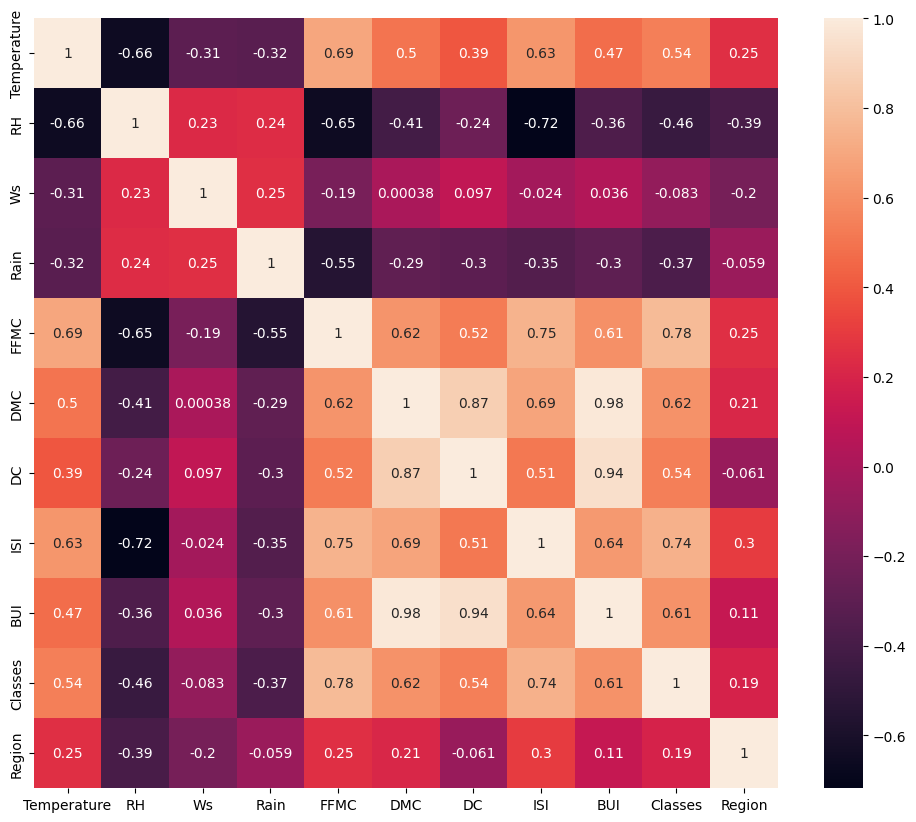

In [16]:

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,annot=True)

In [17]:
def correlation(dataset,threshold):
  col_corr=set()
  coll_matrix=dataset.corr()
  for i in range(len(corr_matrix.columns)):
    for j in range(i):
      if abs(corr_matrix.iloc[i,j])>threshold:
        colname=corr_matrix.columns[i]
        col_corr.add(colname)
  return col_corr

In [18]:
print(correlation(X_train,0.85)) # here we have setup the threshold to be 0.85 but its generally done by domain expert

{'BUI', 'DC'}


In [19]:
# So here we can see that BUI and DC columns has high correlation
# BUI with column DMC and DC (as per heatmap) &
# DC with column DMC and BUI
# So we are going to remove these columns to simply our model working


In [20]:
# Dropping feature BUI and DC. It has to be dropped from both test and train data set

X_train=X_train.drop(["BUI","DC"],axis=1)
X_test=X_test.drop(["BUI","DC"],axis=1)

# Feature Scaling or Standardization

In [21]:

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [22]:
X_train_scaled


array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]])

Text(0.5, 1.0, 'After Scaling')

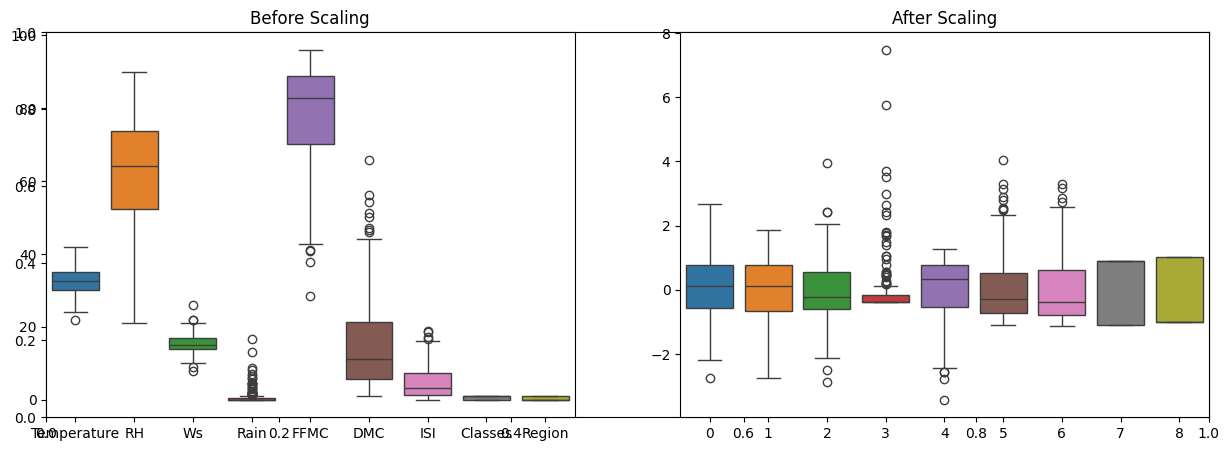

In [23]:
# Boxplot to understand the effect of standard scaleup
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("Before Scaling")
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("After Scaling")

# Linear Regression Model

In [24]:
Lin_reg=LinearRegression()
Lin_reg.fit(X_train_scaled,y_train)

LinearRegression()

In [25]:
y_pred=Lin_reg.predict(X_test_scaled)

mae=metrics.mean_absolute_error(y_test,y_pred)
mse=metrics.mean_squared_error(y_test,y_pred)
r2=metrics.r2_score(y_test,y_pred)
rmse=np.sqrt(mse)

In [26]:
print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("R2 Score:",r2)

Mean Absolute Error: 0.5468236465249986
Mean Squared Error: 0.6742766873791607
Root Mean Squared Error: 0.8211435242265268
R2 Score: 0.9847657384266951


Text(0.5, 1.0, 'Actual vs Predicted Values')

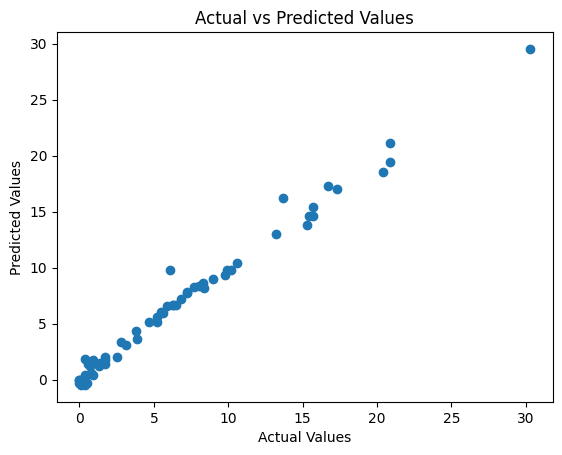

In [27]:
#showing the finding in scatter plot diagram

plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
# plt.show()

# Lasso Regression

In [28]:
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)

mae=metrics.mean_absolute_error(y_test,y_pred)
mse=metrics.mean_squared_error(y_test,y_pred)
r2=metrics.r2_score(y_test,y_pred)


In [29]:
print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("R2 Score:",r2)

Mean Absolute Error: 1.133175994914409
Mean Squared Error: 2.2483458918974772
R2 Score: 0.9492020263112388


Text(0.5, 1.0, 'Actual vs Predicted Values')

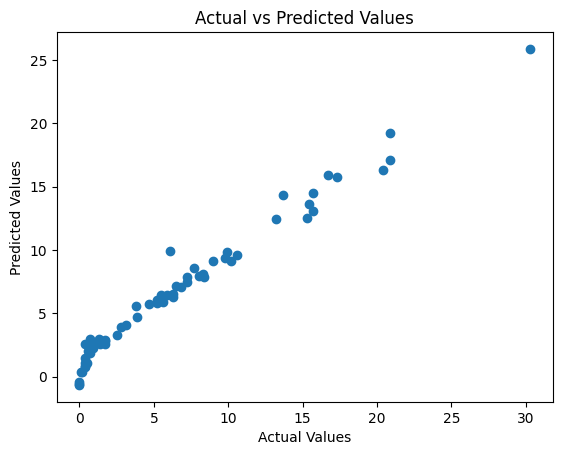

In [30]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")


# Ridge Regression Model

In [31]:
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)

mae=metrics.mean_absolute_error(y_test,y_pred)
mse=metrics.mean_squared_error(y_test,y_pred)
r2=metrics.r2_score(y_test,y_pred)

In [32]:
print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("R2 Score:",r2)

Mean Absolute Error: 0.5642305340105692
Mean Squared Error: 0.6949198918152074
R2 Score: 0.9842993364555513


Text(0.5, 1.0, 'Actual vs Predicted Values')

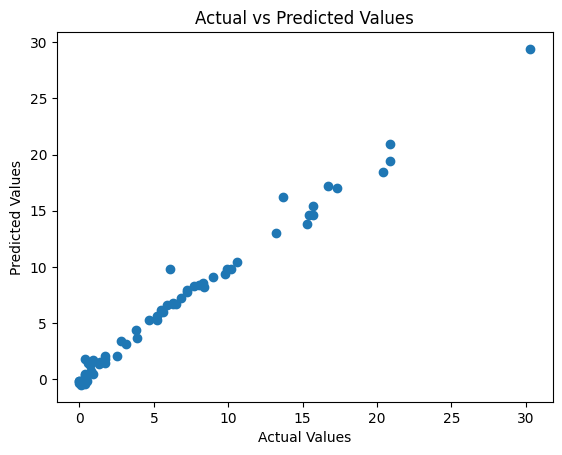

In [33]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

# Elasticnet Regression

In [34]:
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)

mae=metrics.mean_absolute_error(y_test,y_pred)
mse=metrics.mean_squared_error(y_test,y_pred)
r2=metrics.r2_score(y_test,y_pred)

In [35]:
print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("R2 Score:",r2)

Mean Absolute Error: 1.8822353634896005
Mean Squared Error: 5.5172511010252245
R2 Score: 0.8753460589519703


Text(0.5, 1.0, 'Actual vs Predicted Values')

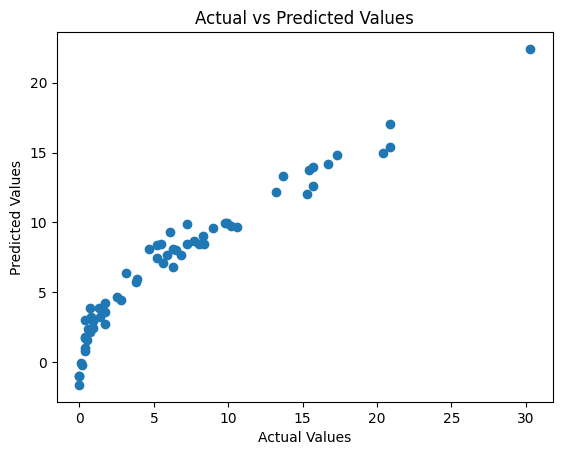

In [36]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

_____________________________
# Cross Validation LassoCV

In [37]:
lasso_cv=LassoCV(cv=5)
lasso_cv.fit(X_train_scaled,y_train)

y_pred=lasso_cv.predict(X_test_scaled)

In [38]:
print("Selected Alpha",lasso_cv.alpha_)

Selected Alpha 0.05725391318234408


In [39]:
print("Tried Alpha",lasso_cv.alphas_) # default tried alpha value will be 100 tries


Tried Alpha [7.05853002 6.58280872 6.13914944 5.72539132 5.33951911 4.97965339
 4.64404142 4.33104857 4.03915039 3.76692517 3.51304702 3.27627941
 3.05546914 2.84954075 2.65749124 2.47838523 2.31135036 2.15557308
 2.01029467 1.87480753 1.74845178 1.63061198 1.52071419 1.41822315
 1.32263965 1.23349817 1.15036452 1.0728338  1.00052839 0.93309613
 0.87020857 0.81155943 0.75686304 0.705853   0.65828087 0.61391494
 0.57253913 0.53395191 0.49796534 0.46440414 0.43310486 0.40391504
 0.37669252 0.3513047  0.32762794 0.30554691 0.28495408 0.26574912
 0.24783852 0.23113504 0.21555731 0.20102947 0.18748075 0.17484518
 0.1630612  0.15207142 0.14182231 0.13226397 0.12334982 0.11503645
 0.10728338 0.10005284 0.09330961 0.08702086 0.08115594 0.0756863
 0.0705853  0.06582809 0.06139149 0.05725391 0.05339519 0.04979653
 0.04644041 0.04331049 0.0403915  0.03766925 0.03513047 0.03276279
 0.03055469 0.02849541 0.02657491 0.02478385 0.0231135  0.02155573
 0.02010295 0.01874808 0.01748452 0.01630612 0.0152

In [40]:
print("MSE Paths",lasso_cv.mse_path_) # This will be set of 500 values


MSE Paths [[53.64536329 65.39074075 54.89628985 77.90299066 39.38236846]
 [46.99139716 59.81506814 49.29840831 75.6645852  35.31758355]
 [41.14908917 53.9178721  42.49594889 68.35708298 31.76996123]
 [36.05788169 48.41773965 36.66879347 61.92819453 28.67296816]
 [31.62067285 42.76466229 31.68391904 56.26841266 24.93183295]
 [27.75285367 37.81922812 27.42599138 51.28216115 21.56888645]
 [24.3807738  33.49107651 23.7950306  45.25481907 18.66094162]
 [21.44052804 29.70161639 20.70460191 39.90418045 16.14837778]
 [18.876308   26.38208059 18.07969934 35.23429953 13.97821475]
 [16.63960395 23.47341883 15.85530749 31.15712074 12.10483403]
 [14.68819307 20.92329068 13.97555108 27.59649208 10.48862803]
 [12.98525144 18.68636627 12.39173305 24.48611006  9.09521221]
 [11.49893734 16.72312788 11.06186319 21.7677198   7.89445038]
 [10.2013182  14.9991189   9.94965275 19.39216316  6.86106557]
 [ 9.06814642 13.48429046  9.02375611 17.31505177  5.9722389 ]
 [ 8.0783105  12.15220147  8.25686268 15.4982

Text(0.5, 1.0, 'Actual vs Predicted Values')

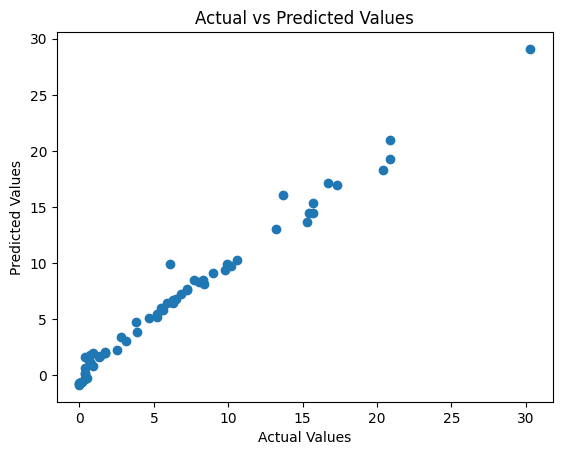

In [41]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")


In [42]:
mae=metrics.mean_absolute_error(y_test,y_pred)
mse=metrics.mean_squared_error(y_test,y_pred)
r2=metrics.r2_score(y_test,y_pred)

print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("R2 Score:",r2)

Mean Absolute Error: 0.619970115826343
Mean Squared Error: 0.792499555474362
R2 Score: 0.9820946715928275


# Cross validation Ridge CV

In [43]:
ridge_cv=RidgeCV(cv=5)
ridge_cv.fit(X_train_scaled,y_train)

y_pred=ridge_cv.predict(X_test_scaled)

In [44]:
mae=metrics.mean_absolute_error(y_test,y_pred)
mse=metrics.mean_squared_error(y_test,y_pred)
r2=metrics.r2_score(y_test,y_pred)

print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("R2 Score:",r2)

Mean Absolute Error: 0.5642305340105692
Mean Squared Error: 0.6949198918152074
R2 Score: 0.9842993364555513


Text(0.5, 1.0, 'Actual vs Predicted Values')

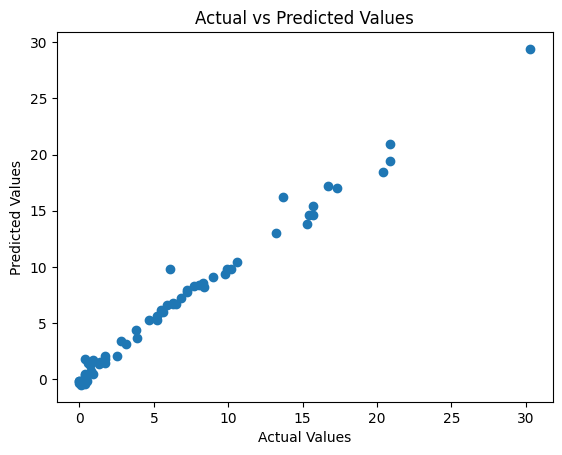

In [45]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

In [46]:
print("Selected Alpha",ridge_cv.alpha_)

Selected Alpha 1.0


# Elasticnet CV

In [47]:
elastic_cv=ElasticNetCV(cv=5)
elastic_cv.fit(X_train_scaled,y_train)

y_pred=elastic_cv.predict(X_test_scaled)

In [48]:
mae=metrics.mean_absolute_error(y_test,y_pred)
mse=metrics.mean_squared_error(y_test,y_pred)
r2=metrics.r2_score(y_test,y_pred)

print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("R2 Score:",r2)

Mean Absolute Error: 0.6575946731430898
Mean Squared Error: 0.8222830416276258
R2 Score: 0.9814217587854941


Text(0.5, 1.0, 'Actual vs Predicted Values')

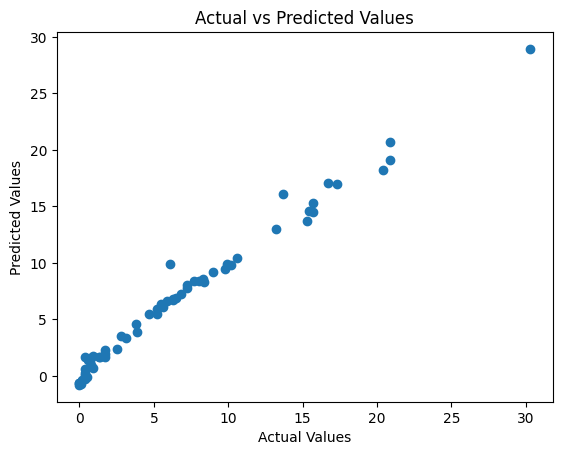

In [49]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

In [50]:
print("Selected Alpha",elastic_cv.alpha_)

Selected Alpha 0.04311146156383891


In [52]:
print("Selected Alpha",elastic_cv.alphas_)

Selected Alpha [14.11706004 13.16561744 12.27829889 11.45078264 10.67903821  9.95930678
  9.28808283  8.66209714  8.07830078  7.53385034  7.02609405  6.55255882
  6.11093829  5.6990815   5.31498248  4.95677045  4.62270071  4.31114616
  4.02058933  3.74961507  3.49690356  3.26122397  3.04142839  2.83644629
  2.64527931  2.46699633  2.30072904  2.1456676   2.00105679  1.86619226
  1.74041714  1.62311885  1.51372607  1.411706    1.31656174  1.22782989
  1.14507826  1.06790382  0.99593068  0.92880828  0.86620971  0.80783008
  0.75338503  0.7026094   0.65525588  0.61109383  0.56990815  0.53149825
  0.49567705  0.46227007  0.43111462  0.40205893  0.37496151  0.34969036
  0.3261224   0.30414284  0.28364463  0.26452793  0.24669963  0.2300729
  0.21456676  0.20010568  0.18661923  0.17404171  0.16231189  0.15137261
  0.1411706   0.13165617  0.12278299  0.11450783  0.10679038  0.09959307
  0.09288083  0.08662097  0.08078301  0.0753385   0.07026094  0.06552559
  0.06110938  0.05699082  0.05314982 